# Libreta para documentar el entrenamiento y evaluación del modelo

Importación de librerías y carga de datos usando la función definida en preprocessing.py.

In [7]:
import joblib
import os
import sys
from xgboost import XGBClassifier

sys.path.append(os.path.abspath(".."))

from src.preprocessing import cargar_datos, separar_escalar_datos

df = cargar_datos("../data/creditcard.csv")

print("Datos cargados con éxito.")

Datos cargados con éxito.


Uso la otra función de preprocessing.py para separar y escalar los datos.

In [8]:
X_train, X_test, y_train, y_test = separar_escalar_datos(df)

print("Datos separados y escalados con éxito.")

Datos separados y escalados con éxito.


## 1. Cálculo del factor de balanceo
El factor de balanceo sirve para corregir el desbalanceo extremo que hay en el dataset entre transacciones normales y fraudes, para que el modelo no ignore la clase minoritaria que son los fraudes.
- Multiplica el castigo cada vez que no se detecta un fraude.
- Sin este ajuste, el modelo siempre prediciría que no es un fraude.
- Fuerza al algoritmo a priorizar la captura de casos raros, elevando la PRECISIÓN.

In [11]:
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
factor_balanceo = num_neg / num_pos

print(f"Número de casos positivos: {num_pos}")
print(f"Número de casos negativos: {num_neg}")
print(f"Factor de balanceo (negativos/positivos): {factor_balanceo:.4f}")

Número de casos positivos: 394
Número de casos negativos: 227451
Factor de balanceo (negativos/positivos): 577.2868


## 2. Creación del modelo

In [12]:
model = XGBClassifier(
    scale_pos_weight = factor_balanceo,
    random_state = 42,
    eval_metric = "logloss"
)

## 3. Entrenamiento del modelo

In [14]:
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 4. Evaluación del modelo

MATRIZ DE CONFUSIÓN:

[[56852    12]
 [   17    81]]


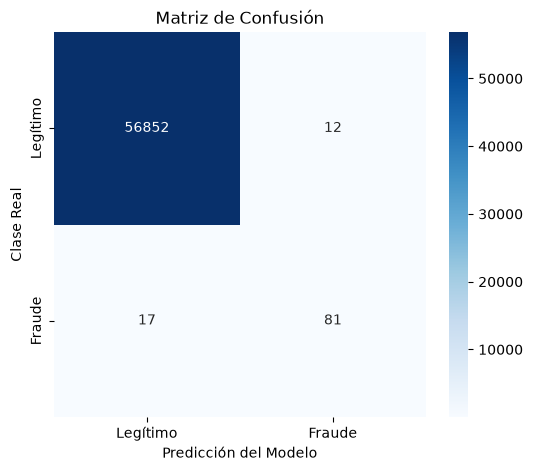

In [22]:
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]       # Porbabilidad de que la transaccion sea un fraude

print("MATRIZ DE CONFUSIÓN:\n")
print(confusion_matrix(y_test, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legítimo', 'Fraude'], 
            yticklabels=['Legítimo', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.show()

Esta es la matriz de confusión, que muestra:
- Verdaderos negativos (56852): el modelo predice correctamente este número de transacciones como 0.
- Falso positivo (12): predice 12 transacciones como fraude cuando no lo son.
- Falso negativo (17): predice 17 transacciones como no fraude cuando sí lo son.
- Verdadero positivo (81): predice bien 81 transacciones como fraude.

Con estos datos, se pueden calcular las métricas: PRECISIÓN, RECALL y F1-SCORE.

PRECISIÓN: 0.8710
RECALL: 0.8265
F1-SCORE: 0.8482


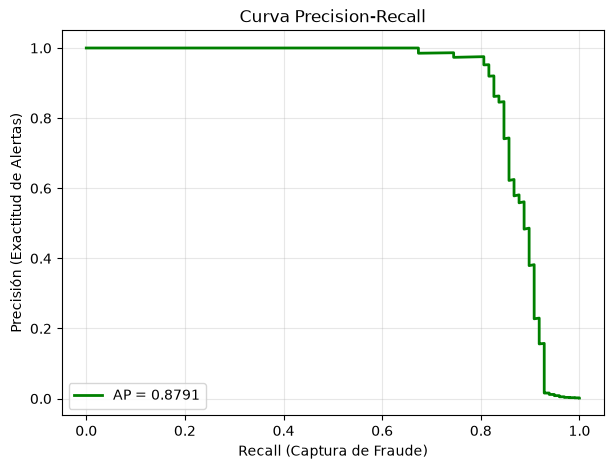

In [25]:
v_neg, f_pos, f_neg, v_pos = confusion_matrix(y_test, y_pred).ravel()

precision = v_pos / (v_pos + f_pos)
recall = v_pos / (v_pos + f_neg)
f1 = f1_score(y_test, y_pred)

print(f"PRECISIÓN: {precision:.4f}")
print(f"RECALL: {recall:.4f}")
print(f"F1-SCORE: {f1:.4f}")


from sklearn.metrics import precision_recall_curve, average_precision_score

precision_pts, recall_pts, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall_pts, precision_pts, color='green', lw=2, label=f'AP = {ap_score:.4f}')
plt.xlabel('Recall (Captura de Fraude)')
plt.ylabel('Precisión (Exactitud de Alertas)')
plt.title('Curva Precision-Recall')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

- PRECISIÓN: de cada 100 transacciones que predice como fraude, cuántas son realmente fraude.
- RECALL: de cada 100 fraudes, cuántos predice como fraude.
- F1-SCORE: equilibrio entre precisión y recall.

ROC-AUC Score: 0.9725846057331204


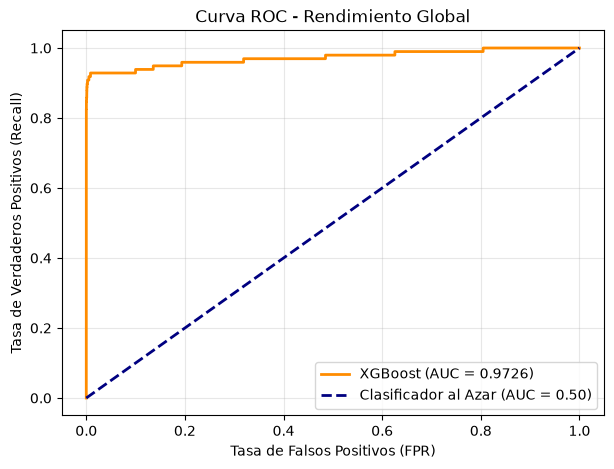

In [24]:
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob)}")

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador al Azar (AUC = 0.50)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Rendimiento Global')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## Gráfica con las 10 variables más importantes

En esta gráfica se pueden ver las variables que más importantes son a la hora de predecir si una transacción es fraude o no. Se puede ver que V14 es con mucha diferencia la más trascendente.

<Figure size 800x600 with 0 Axes>

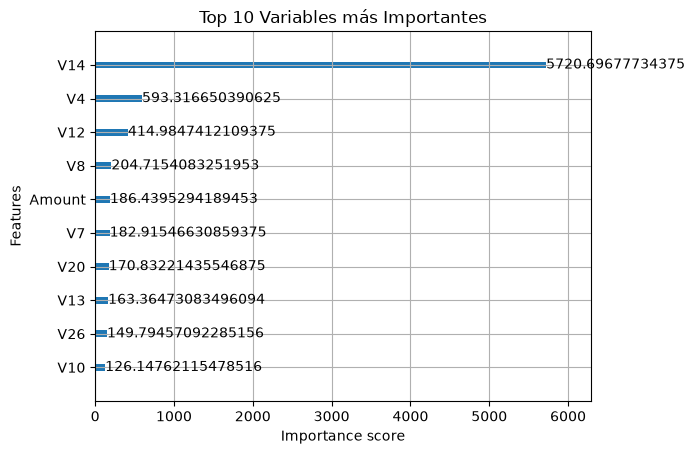

In [26]:
from xgboost import plot_importance

plt.figure(figsize=(8, 6))
# Muestra las 10 variables más influyentes
plot_importance(model, max_num_features=10, importance_type='gain', title='Top 10 Variables más Importantes')
plt.show()

## Gráfica de separación de clases

Esta gráfica muestra la separación de las clases de una transacción. Cuanto menos se solapen, mejor será el modelo a la hora de predecir nuevas transacciones.

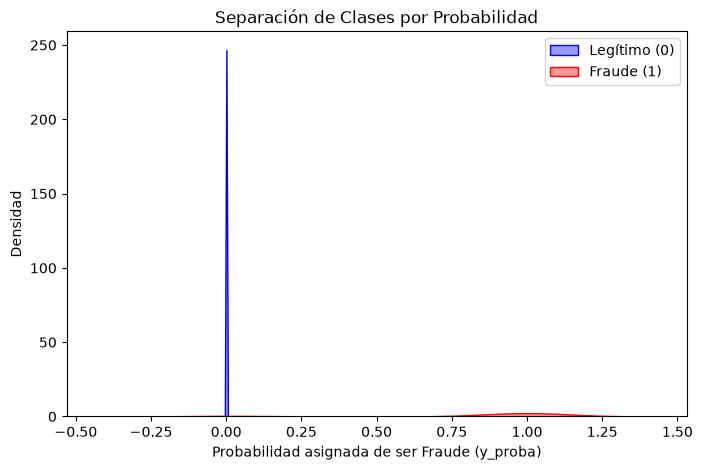

In [27]:
plt.figure(figsize=(8, 5))
sns.kdeplot(y_prob[y_test == 0], label='Legítimo (0)', color='blue', fill=True, alpha=0.4)
sns.kdeplot(y_prob[y_test == 1], label='Fraude (1)', color='red', fill=True, alpha=0.4)
plt.xlabel('Probabilidad asignada de ser Fraude (y_proba)')
plt.ylabel('Densidad')
plt.title('Separación de Clases por Probabilidad')
plt.legend()
plt.show()